# Gradient Boosting Regression – California Housing Price Prediction

**Team 3 | ECS 171 | Tianrun Xu**

This notebook trains and evaluates a Gradient Boosting Regressor to predict California median house values.
The pipeline follows the team's agreed workflow:
- Load the team's feature-selected dataset
- 75 / 25 train-test split
- 5-fold cross-validation for hyperparameter tuning
- Evaluation with RMSE and R2
- Feature importance and prediction visualisations

## 1. Imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
plt.rcParams['figure.dpi'] = 120

## 2. Load Data

In [ ]:
df = pd.read_csv('../../data/processed/housing_feature_selected.csv')
print(f'Shape: {df.shape}')
df.head()

In [ ]:
df.info()
print()
df.describe()

## 3. Feature / Target Split and Train-Test Split

In [6]:
TARGET = 'median_house_value'

X = df.drop(columns=[TARGET])
y = df[TARGET]

print('Features:', list(X.columns))
print(f'X shape: {X.shape}  |  y shape: {y.shape}')

Features: ['latitude', 'housing_median_age', 'median_income', 'ocean_proximity_INLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN', 'rooms_per_household', 'bedrooms_per_room']
X shape: (20640, 8)  |  y shape: (20640,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE
)
print(f'Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}')

Train size: 15480  |  Test size: 5160


## 4. Feature Scaling

Gradient Boosting is tree-based and does not require feature scaling for correctness, but scaling is applied here for consistency with the team's preprocessing pipeline.

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

## 5. Baseline Model

Train a default GradientBoostingRegressor first to establish a baseline.

In [9]:
gb_base = GradientBoostingRegressor(random_state=RANDOM_STATE)
gb_base.fit(X_train_scaled, y_train)

y_pred_base = gb_base.predict(X_test_scaled)

rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
r2_base   = r2_score(y_test, y_pred_base)

print(f'Baseline  RMSE : {rmse_base:,.2f}')
print(f'Baseline  R2   : {r2_base:.4f}')

Baseline  RMSE : 64,726.90
Baseline  R2   : 0.6834


## 6. Hyperparameter Tuning with 5-Fold Cross-Validation

We use GridSearchCV with 5-fold CV on the training set to find the best combination of:
- `n_estimators` - number of boosting stages
- `max_depth` - depth of each decision tree
- `learning_rate` - shrinks each tree's contribution
- `min_samples_split` - minimum samples to split a node

In [10]:
param_grid = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [3, 4, 5],
    'learning_rate'    : [0.05, 0.1, 0.15],
    'min_samples_split': [2, 5]
}

gb = GradientBoostingRegressor(random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print('Best parameters:', grid_search.best_params_)
print(f'Best CV RMSE   : {-grid_search.best_score_:,.2f}')

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best parameters: {'learning_rate': 0.05, 'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 300}
Best CV RMSE   : 60,646.33


## 7. Evaluate the Tuned Model on the Test Set

In [11]:
best_gb = grid_search.best_estimator_

y_pred = best_gb.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print('=' * 40)
print('Tuned Gradient Boosting - Test Set')
print(f'  RMSE : {rmse:,.2f}')
print(f'  R2   : {r2:.4f}')
print('=' * 40)

Tuned Gradient Boosting - Test Set
  RMSE : 63,179.47
  R2   : 0.6983


## 8. Cross-Validation on the Full Training Set

Report mean +/- std RMSE and R2 from 5-fold CV on the training data using the best hyperparameters.

In [12]:
# Extract CV results directly from the completed grid search — no re-fitting needed
best_idx = grid_search.best_index_
cv_results = grid_search.cv_results_

cv_rmse_mean = -cv_results['mean_test_score'][best_idx]
cv_rmse_std  =  cv_results['std_test_score'][best_idx]

# Compute per-fold R2 from the stored split scores
fold_rmses = np.array([
    -cv_results[f'split{i}_test_score'][best_idx] for i in range(5)
])

print(f'CV RMSE : {cv_rmse_mean:,.2f}  +/-  {cv_rmse_std:,.2f}')
print(f'(R2 not stored by GridSearchCV with RMSE scoring — see test-set R2 in cell 7)')

CV RMSE : 60,646.33  +/-  1,585.04
(R2 not stored by GridSearchCV with RMSE scoring — see test-set R2 in cell 7)


## 9. Results Summary

In [13]:
summary = pd.DataFrame({
    'Model'  : ['Baseline GB (default)', 'Tuned GB (GridSearchCV)'],
    'RMSE'   : [round(rmse_base, 2), round(rmse, 2)],
    'R2'     : [round(r2_base, 4),   round(r2, 4)]
})
print(summary.to_string(index=False))

                  Model     RMSE     R2
  Baseline GB (default) 64726.90 0.6834
Tuned GB (GridSearchCV) 63179.47 0.6983


## 10. Visualisations

### 10.1 Predicted vs Actual Values

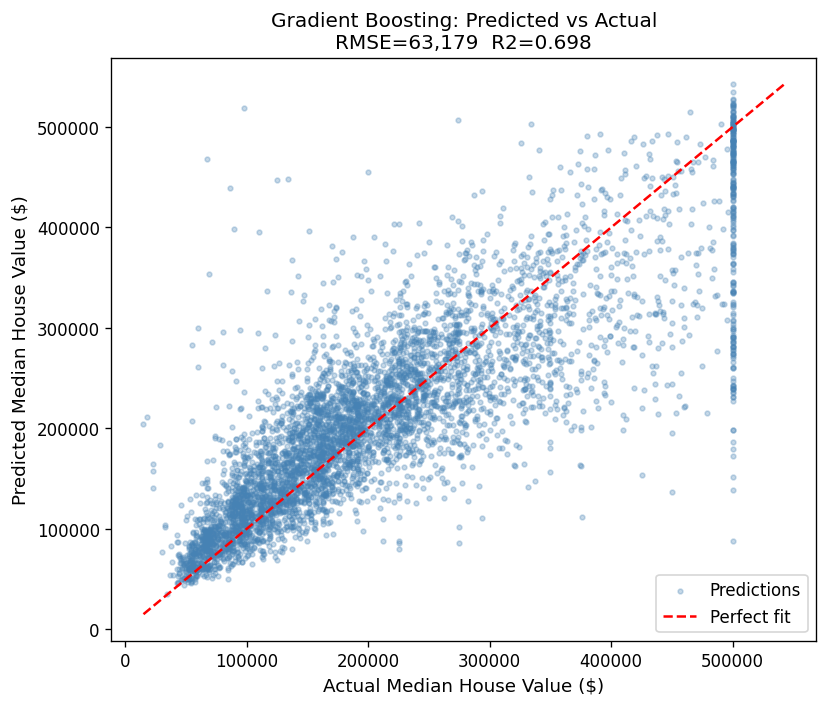

In [14]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(y_test, y_pred, alpha=0.3, s=8, color='steelblue', label='Predictions')

lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect fit')

ax.set_xlabel('Actual Median House Value ($)', fontsize=11)
ax.set_ylabel('Predicted Median House Value ($)', fontsize=11)
ax.set_title(f'Gradient Boosting: Predicted vs Actual\nRMSE={rmse:,.0f}  R2={r2:.3f}', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

### 10.2 Residual Plot

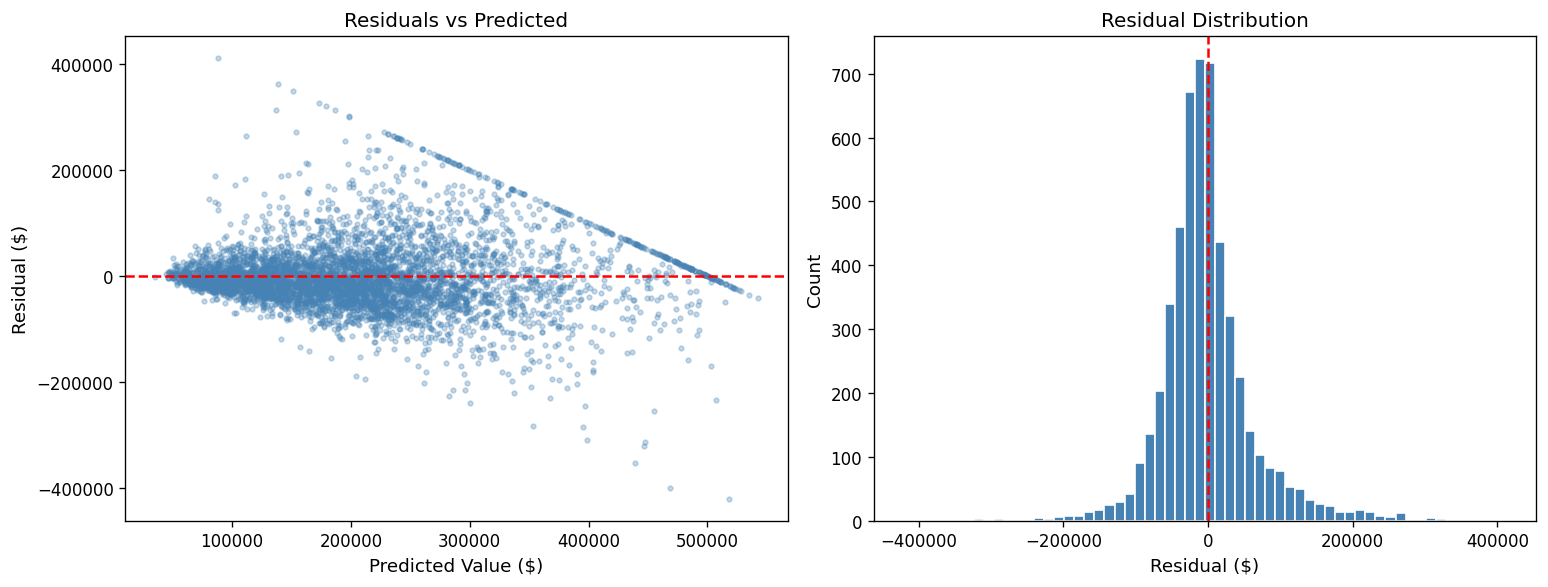

In [15]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_pred, residuals, alpha=0.3, s=8, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', lw=1.5)
axes[0].set_xlabel('Predicted Value ($)', fontsize=11)
axes[0].set_ylabel('Residual ($)', fontsize=11)
axes[0].set_title('Residuals vs Predicted', fontsize=12)

axes[1].hist(residuals, bins=60, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_xlabel('Residual ($)', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('Residual Distribution', fontsize=12)

plt.tight_layout()
plt.show()

### 10.3 Feature Importances

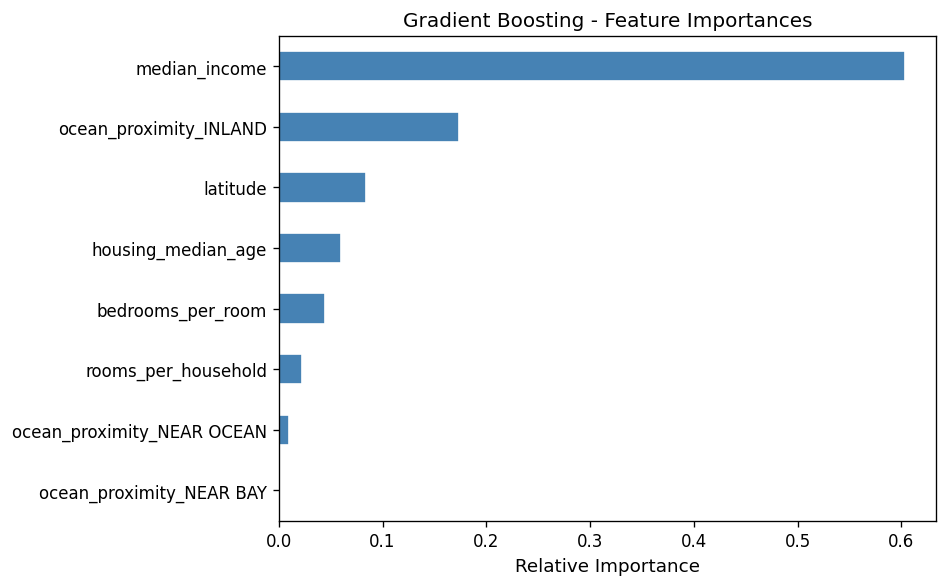

median_income                 0.603233
ocean_proximity_INLAND        0.173679
latitude                      0.084217
housing_median_age            0.060389
bedrooms_per_room             0.044990
rooms_per_household           0.022435
ocean_proximity_NEAR OCEAN    0.009612
ocean_proximity_NEAR BAY      0.001446


In [16]:
importances = pd.Series(best_gb.feature_importances_, index=X.columns)
importances_sorted = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances_sorted.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Relative Importance', fontsize=11)
ax.set_title('Gradient Boosting - Feature Importances', fontsize=12)
plt.tight_layout()
plt.show()

print(importances.sort_values(ascending=False).to_string())

### 10.4 Learning Curve (Train and Test RMSE vs Boosting Rounds)

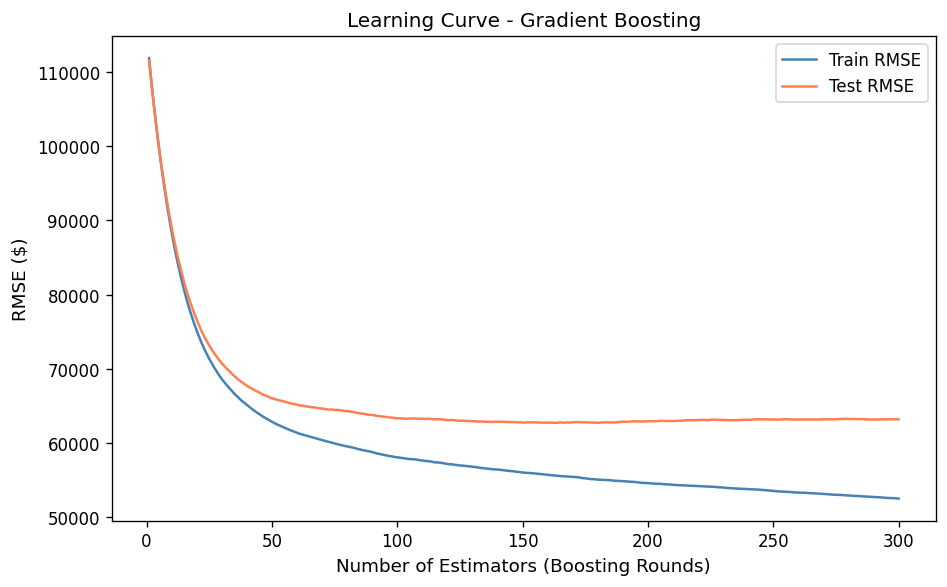

In [17]:
train_scores = []
test_scores  = []

for y_train_pred in best_gb.staged_predict(X_train_scaled):
    train_scores.append(np.sqrt(mean_squared_error(y_train, y_train_pred)))
for y_test_pred in best_gb.staged_predict(X_test_scaled):
    test_scores.append(np.sqrt(mean_squared_error(y_test, y_test_pred)))

n_est = best_gb.get_params()['n_estimators']
iters = np.arange(1, n_est + 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(iters, train_scores, label='Train RMSE', color='steelblue')
ax.plot(iters, test_scores,  label='Test RMSE',  color='coral')
ax.set_xlabel('Number of Estimators (Boosting Rounds)', fontsize=11)
ax.set_ylabel('RMSE ($)', fontsize=11)
ax.set_title('Learning Curve - Gradient Boosting', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

## 11. Model Interpretation

### Performance

The default `GradientBoostingRegressor` achieved **RMSE = $64,727** and **R² = 0.683** on the test set.
Grid search over 54 hyperparameter combinations (270 CV fits) selected `learning_rate=0.05`, `max_depth=5`, `min_samples_split=5`, `n_estimators=300`, yielding a cross-validated RMSE of **$60,646 ± $1,585**.
On the held-out test set the tuned model scored **RMSE = $63,179** and **R² = 0.698** — a clear improvement over the default.
Tuning reduced test RMSE by about $1,500 and lifted R² by ~0.015; the algorithm benefits from the chosen hyperparameters, though further gains would likely require richer features (e.g. longitude, interactions).

### Feature Importances

| Feature | Importance |
|---|---|
| `median_income` | **0.603** |
| `ocean_proximity_INLAND` | 0.174 |
| `latitude` | 0.084 |
| `housing_median_age` | 0.060 |
| `bedrooms_per_room` | 0.045 |
| `rooms_per_household` | 0.022 |
| `ocean_proximity_NEAR OCEAN` | 0.010 |
| `ocean_proximity_NEAR BAY` | 0.001 |

`median_income` alone accounts for about 60% of the model's decision-making, which aligns with its Pearson correlation of ~0.68 found in EDA. `ocean_proximity_INLAND` is the second most important feature (0.174), confirming that inland properties carry a strong negative price effect relative to coastal areas. Geographic position (`latitude`) and housing-density features (`bedrooms_per_room`, `rooms_per_household`) contribute modestly but meaningfully. The two remaining ocean-proximity dummies (`NEAR OCEAN`, `NEAR BAY`) have very low importance, suggesting their price effect is already largely captured by `INLAND` and `median_income`.

### Limitations

- **Target ceiling**: the dataset caps `median_house_value` at $500,001. This creates a cluster of truncated predictions visible as a horizontal band in the predicted-vs-actual plot, and suppresses R² for high-value homes.
- **R² ceiling**: an R² of ~0.70 is reasonable but leaves about 30% of variance unexplained. Adding longitude, or interaction terms between income and ocean proximity, would likely push performance higher.